# Step 1: Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv('data.csv', on_bad_lines='skip')

df.head()

,password,strength
0,kzde5577,1
1,kino3434,1
2,visi7k1yr,1
3,megzy123,1
4,lamborghin1,1


In [3]:
df.shape

(669640, 2)

In [4]:
df.columns

Index(['password', 'strength'], dtype='object')

# Step 2: Check for any null values

In [5]:
df.isnull().sum()

password    1
strength    0
dtype: int64

# Step 3: Data Cleaning

In [6]:
df.dropna(inplace=True)

In [7]:
df.isnull().sum()

password    0
strength    0
dtype: int64

# Step 4: Exploratory Data Analysis(EDA)

In [8]:
df["strength"].value_counts()

strength
1    496801
0     89701
2     83137
Name: count, dtype: int64

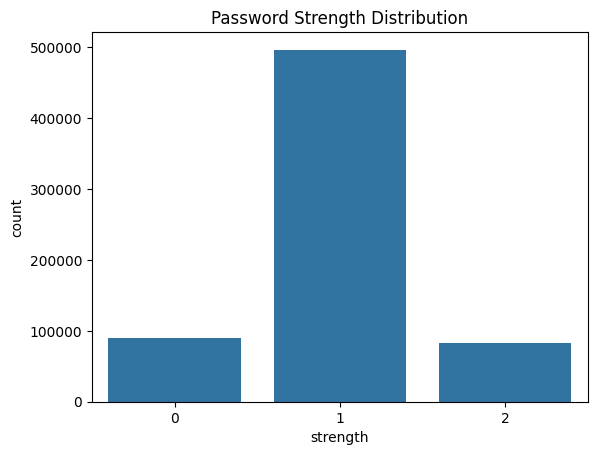

In [9]:
sns.countplot(x="strength", data=df)
plt.title("Password Strength Distribution")
plt.show()

# Step 5: Features and Target

In [10]:
X = df["password"]
y = df["strength"]

# Step 6: Convert Text to Numerical Features (TF-IDF)

## Machine learning cannot read text directly.

## We convert passwords to numerical vectors using TF-IDF.

In [11]:
vectorizer = TfidfVectorizer(analyzer="char")

X = vectorizer.fit_transform(X)

# Step 7: Train Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 8: Training Models

### Logistic Regression

In [13]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

### Naive Bayes

In [14]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

# Step 9: Model Evaluation

### Logistic Regression

In [15]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8205080341676124


### Naive Bayes

In [16]:
print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.7446090436652529


# Step 10: Classification Report

In [17]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.62      0.00      0.00     17908
           1       0.75      1.00      0.85     99519
           2       0.54      0.03      0.06     16501

    accuracy                           0.74    133928
   macro avg       0.64      0.34      0.30    133928
weighted avg       0.70      0.74      0.64    133928



# Step 11: Saving Model and Vectorizer

In [18]:
import pickle

pickle.dump(nb, open("model.pkl", "wb"))

pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

# Step 12: Test Prediction

In [20]:
password = ["P@ssw0rd123#@!"]

data = vectorizer.transform(password)

prediction = nb.predict(data)

print(prediction)

[2]
